# Assessment | Statistical Evaluation Mini-Project

Work through the four tasks below using the **Auto MPG** dataset. Each task has its own section with scaffolding cells — add as many code and markdown cells as you need.

## Setup

Run the cell below to load the dataset and verify everything is working.

In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)

mpg = sns.load_dataset("mpg").dropna()

print(f"Rows: {len(mpg)}, Columns: {mpg.shape[1]}")
print(f"Origin groups: {mpg['origin'].unique().tolist()}")
mpg.head()

Rows: 392, Columns: 9
Origin groups: ['usa', 'japan', 'europe']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [105]:
mpg.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


---
## Task 1 — Correlation Analysis

1. Choose at least three pairs of numeric variables and compute Pearson and Spearman correlations.
2. Test each for significance (report p-values).
3. Create a correlation heatmap and at least two scatter plots with regression lines.
4. Explain when Pearson vs. Spearman is more appropriate, using your results as examples.

In [106]:
pearson_r, p_pearson = stats.pearsonr(mpg['mpg'], mpg['weight'])
spearman_r, p_spearman = stats.spearmanr(mpg['mpg'], mpg['weight'])
print("Pair 1: mpg and weight")
print(f"Pearson: {pearson_r:.4f}, p: {p_pearson:.4f}")
print(f"Spearman: {spearman_r:.4f}, p: {p_spearman:.4f}")
pearson_r, p_pearson = stats.pearsonr(mpg['cylinders'], mpg['horsepower'])
spearman_r, p_spearman = stats.spearmanr(mpg['cylinders'], mpg['horsepower'])
print("Pair 2: cylinders and horsepower")
print(f"Pearson: {pearson_r:.4f}, p: {p_pearson:.4f}")
print(f"Spearman: {spearman_r:.4f}, p: {p_spearman:.4f}")
pearson_r, p_pearson = stats.pearsonr(mpg['weight'], mpg['acceleration'])
spearman_r, p_spearman = stats.spearmanr(mpg['weight'], mpg['acceleration'])
print("Pair 1: weight and acceleration")
print(f"Pearson: {pearson_r:.4f}, p: {p_pearson:.4f}")
print(f"Spearman: {spearman_r:.4f}, p: {p_spearman:.4f}")

Pair 1: mpg and weight
Pearson: -0.8322, p: 0.0000
Spearman: -0.8756, p: 0.0000
Pair 2: cylinders and horsepower
Pearson: 0.8430, p: 0.0000
Spearman: 0.8162, p: 0.0000
Pair 1: weight and acceleration
Pearson: -0.4168, p: 0.0000
Spearman: -0.4051, p: 0.0000


<Axes: >

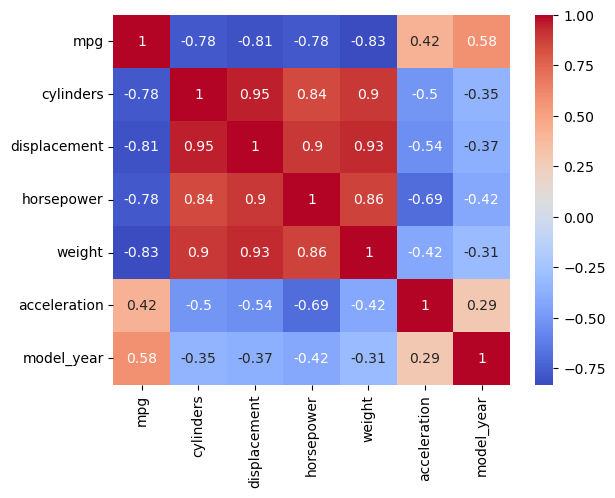

In [107]:
sns.heatmap(mpg.corr(numeric_only=True), annot=True, cmap='coolwarm')

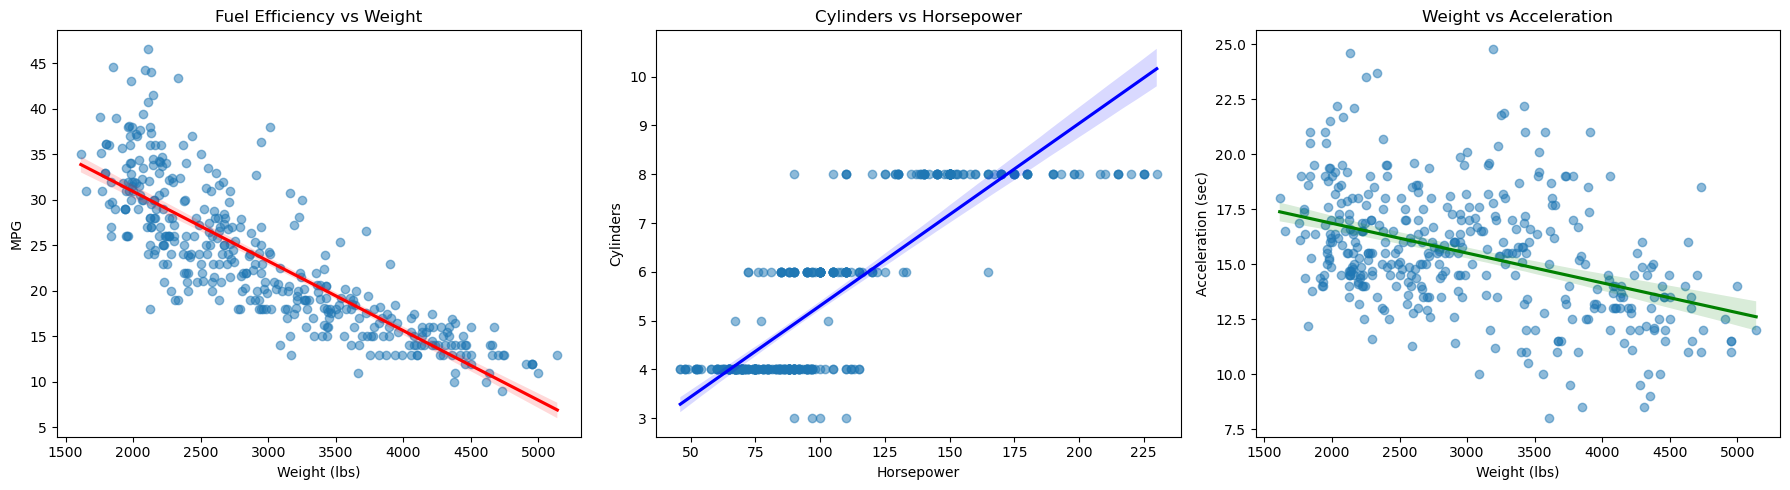

In [108]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# 1. mpg and weight (ax1)
sns.regplot(data=mpg, x='weight', y='mpg', ax=ax1, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
ax1.set_title('Fuel Efficiency vs Weight')
ax1.set_xlabel('Weight (lbs)')
ax1.set_ylabel('MPG')

# 2. cylinders and horsepower (ax2)
sns.regplot(data=mpg, x='horsepower', y='cylinders', ax=ax2, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'blue'})
ax2.set_title('Cylinders vs Horsepower')
ax2.set_xlabel('Horsepower')
ax2.set_ylabel('Cylinders')

# 3. weight and acceleration (ax3)
sns.regplot(data=mpg, x='weight', y='acceleration', ax=ax3, 
            scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
ax3.set_title('Weight vs Acceleration')
ax3.set_xlabel('Weight (lbs)')
ax3.set_ylabel('Acceleration (sec)')

plt.tight_layout()
plt.show()

Pearson correlation is most appropriate when two variables have a linear relationship and follow a normal distribution. It measures the strength of a straight-line connection. On the other hand, Spearman correlation is more appropriate when the relationship is monotonic but not necessarily linear, or when the data contains outliers or is ordinal (discrete categories).

Examples from my results:

**Linearity (Cylinders vs. Horsepower):** In my analysis of cylinders and horsepower, the Pearson coefficient was quite high. However, because cylinders is an ordinal variable , the Spearman correlation is also very relevant here as it focuses on the rank-order rather than assuming a perfect continuous line.

**Robustness to Outliers (MPG vs. Weight):** For mpg and weight, I observed a Pearson of -0.83 and a Spearman of -0.87. The fact that Spearman is slightly stronger suggests that while the relationship is mostly linear, there might be some non-linear trends or outliers in the data (e.g., specific car models that are exceptionally heavy but still relatively efficient). In this case, Spearman provides a more robust measure of the overall trend.

**Monotonic Trends (Weight vs. Acceleration):** My results for weight and acceleration show a moderate relationship. Spearman is useful here to confirm if a general trend exists (heavier cars tending to be faster) without being strictly tied to a specific linear formula, which is helpful given the higher dispersion seen in the scatter plot.

---
## Task 2 — Group Comparisons

1. Choose a numeric variable and visualize its distribution by origin (box/violin plot).
2. Check ANOVA assumptions: Shapiro-Wilk (normality) and Levene's test (equal variances).
3. Run one-way ANOVA — report F-statistic, p-value, and eta-squared.
4. If significant, run Tukey's HSD and state which groups differ.

C:\Users\user\AppData\Local\Temp\ipykernel_15568\3121353922.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=mpg, x='origin', y='mpg', palette='Set2')
C:\Users\user\AppData\Local\Temp\ipykernel_15568\3121353922.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=mpg, x='origin', y='mpg', palette='Set2')


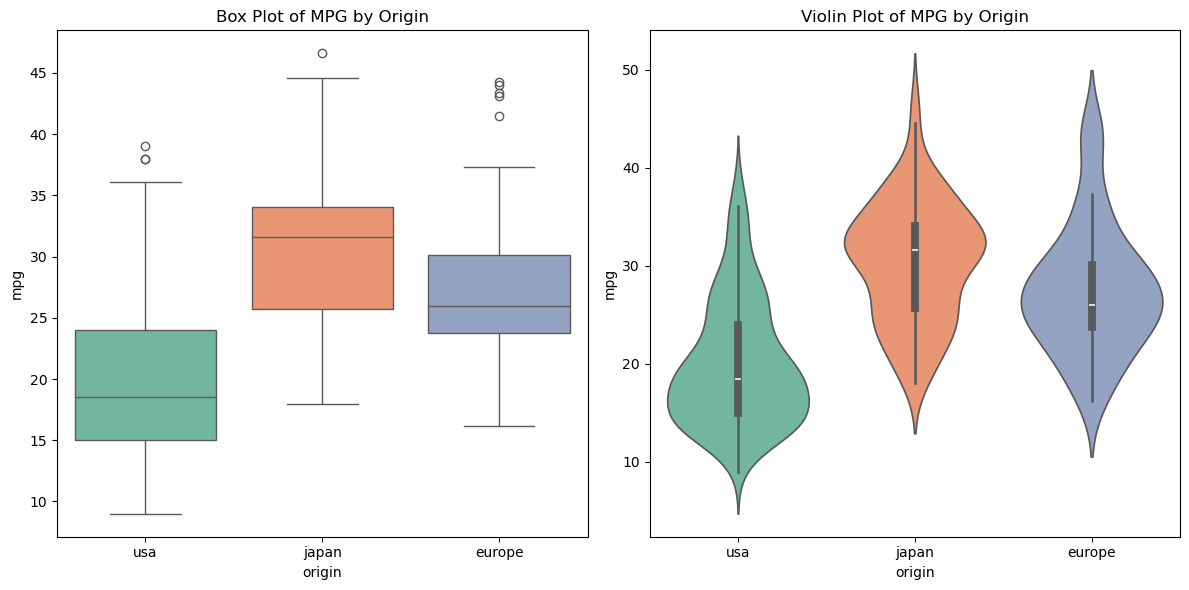

In [109]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=mpg, x='origin', y='mpg', palette='Set2')
plt.title('Box Plot of MPG by Origin')

plt.subplot(1, 2, 2)
sns.violinplot(data=mpg, x='origin', y='mpg', palette='Set2')
plt.title('Violin Plot of MPG by Origin')

plt.tight_layout()
plt.show()


In [110]:
from scipy import stats

usa_mpg    = mpg[mpg['origin'] == 'usa']['mpg']
japan_mpg  = mpg[mpg['origin'] == 'japan']['mpg']
europe_mpg = mpg[mpg['origin'] == 'europe']['mpg']
print("=" * 45)
print("Shapiro-Wilk Normality Test")
print("=" * 45)
normality_ok = True
for name, group in zip(['USA', 'Japan', 'Europe'],
                        [usa_mpg, japan_mpg, europe_mpg]):
    stat, p = stats.shapiro(group)
    result = "Normal" if p > 0.05 else "Not Normal"
    print(f"  {name}: W = {stat:.4f}, p = {p:.4f}  →  {result}")
    if p <= 0.05:
        normality_ok = False

if normality_ok:
    print("\n→ All groups follow a normal distribution.")
    print("  Normality assumption for ANOVA is satisfied.")
else:
    print("\n→ At least one group violates normality.")
    print("  ANOVA is fairly robust, but results should be interpreted with caution.")
    print("  Alternative: Consider using the Kruskal-Wallis test.")
print("\n" + "=" * 45)
print("Levene's Test for Equality of Variances")
print("=" * 45)
stat_l, p_l = stats.levene(usa_mpg, japan_mpg, europe_mpg)
print(f"  W = {stat_l:.4f}, p = {p_l:.4f}")

if p_l > 0.05:
    print("\n→ Variances are equal (homoscedastic).")
    print("  Standard one-way ANOVA is appropriate.")
else:
    print("\n→ Variances are NOT equal (heteroscedastic).")
    print("  Welch's ANOVA is recommended.")
    from scipy.stats import f_oneway
    print("  (Use the pingouin library for Welch's correction)")

Shapiro-Wilk Normality Test
  USA: W = 0.9337, p = 0.0000  →  Not Normal
  Japan: W = 0.9797, p = 0.2420  →  Normal
  Europe: W = 0.9462, p = 0.0054  →  Not Normal

→ At least one group violates normality.
  ANOVA is fairly robust, but results should be interpreted with caution.
  Alternative: Consider using the Kruskal-Wallis test.

Levene's Test for Equality of Variances
  W = 0.0861, p = 0.9175

→ Variances are equal (homoscedastic).
  Standard one-way ANOVA is appropriate.


In [111]:
f_stat, p_val = stats.f_oneway(usa_mpg, japan_mpg, europe_mpg)
all_mpg = mpg['mpg']
grand_mean = all_mpg.mean()
ss_between = (len(usa_mpg) * (usa_mpg.mean() - grand_mean)**2 +
              len(japan_mpg) * (japan_mpg.mean() - grand_mean)**2 +
              len(europe_mpg) * (europe_mpg.mean() - grand_mean)**2)
ss_total = ((all_mpg - grand_mean)**2).sum()

eta_squared = ss_between / ss_total

print(f"ANOVA F-statistic: {f_stat:.4f}")
print(f"ANOVA p-value: {p_val:.4e}")
print(f"Eta-squared: {eta_squared:.4f}")

ANOVA F-statistic: 96.6015
ANOVA p-value: 8.6738e-35
Eta-squared: 0.3318


In [112]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(endog=mpg['mpg'], groups=mpg['origin'], alpha=0.05)
print(tukey)


 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
europe  japan   2.8477 0.0203   0.3583   5.337   True
europe    usa  -7.5695    0.0  -9.6321 -5.5068   True
 japan    usa -10.4172    0.0 -12.3642 -8.4701   True
-----------------------------------------------------


One-way ANOVA shows a significant difference in MPG across regions ($F=96.60$, $p \approx 0$). Tukey HSD confirms that all three groups differ significantly from each other:Japan vs. USA: Japan is the most efficient (+10.42 MPG).Europe vs. USA: Europe is significantly better than USA (+7.57 MPG).Japan vs. Europe: Japan is slightly more efficient (+2.85 MPG).What does the effect size tell you?The Eta-squared ($\eta^2$) of 0.3318 represents a large effect size. This means 33% of the variance in fuel efficiency is explained solely by the car's origin. It proves that origin is a critical predictor of MPG performance.

---
## Task 3 — Classification with Bootstrap Confidence Intervals

1. Prepare features (numeric columns) and target (`origin`). Train/test split (75/25, stratified).
2. Train at least two classifiers with default hyperparameters.
3. Print a classification report for each.
4. Write `bootstrap_metric()` and compute 95 % CIs for F1, precision, and recall.
5. Visualize the CIs and state which model you recommend.

In [113]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

numeric_cols = ["mpg", "cylinders", "displacement", "horsepower",
                "weight", "acceleration", "model_year"]

X = mpg[numeric_cols].values
y = mpg["origin"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Class distribution (test): {pd.Series(y_test).value_counts().to_dict()}")

Train: 294, Test: 98
Class distribution (test): {'usa': 61, 'japan': 20, 'europe': 17}


In [114]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
model_lr = LogisticRegression(max_iter=2000, random_state=SEED)
model_rf = RandomForestClassifier(random_state=SEED)
model_lr.fit(X_train, y_train)
model_rf.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [115]:
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("-" * 60)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

      europe       0.73      0.47      0.57        17
       japan       0.57      0.65      0.60        20
         usa       0.89      0.93      0.91        61

    accuracy                           0.80        98
   macro avg       0.73      0.69      0.70        98
weighted avg       0.80      0.80      0.79        98

------------------------------------------------------------
Random Forest Classification Report:
              precision    recall  f1-score   support

      europe       0.80      0.71      0.75        17
       japan       0.76      0.65      0.70        20
         usa       0.89      0.97      0.93        61

    accuracy                           0.86        98
   macro avg       0.82      0.77      0.79        98
weighted avg       0.85      0.86      0.85        98



In [116]:
def bootstrap_metric(y_true, y_pred, metric_fn, n_boot=2000, seed=42):
    """Compute bootstrap 95% confidence interval for a classification metric."""
    rng = np.random.RandomState(seed)
    n = len(y_true)
    boot_scores = []
    point_estimate = metric_fn(y_true, y_pred, average='weighted')
    
    for _ in range(n_boot):
        indices = rng.randint(0, n, size=n)
        if len(np.unique(y_true[indices])) < 2:
            continue
            
        score = metric_fn(y_true[indices], y_pred[indices], average='weighted')
        boot_scores.append(score)
    ci_lower = np.percentile(boot_scores, 2.5)
    ci_upper = np.percentile(boot_scores, 97.5)
    
    return point_estimate, ci_lower, ci_upper, np.array(boot_scores)

In [117]:
metrics_to_compute = {
    'F1': f1_score,
    'Precision': precision_score,
    'Recall': recall_score
}

bootstrap_results = []

for m_name, m_fn in metrics_to_compute.items():
    p_lr, low_lr, high_lr, _ = bootstrap_metric(y_test, y_pred_lr, m_fn)
    bootstrap_results.append({
        'Model': 'Logistic Regression',
        'Metric': m_name,
        'Score': p_lr,
        'Lower': low_lr,
        'Upper': high_lr
    })
    p_rf, low_rf, high_rf, _ = bootstrap_metric(y_test, y_pred_rf, m_fn)
    bootstrap_results.append({
        'Model': 'Random Forest',
        'Metric': m_name,
        'Score': p_rf,
        'Lower': low_rf,
        'Upper': high_rf
    })
results_df = pd.DataFrame(bootstrap_results)
print(results_df)


                 Model     Metric     Score     Lower     Upper
0  Logistic Regression         F1  0.790197  0.699536  0.873266
1        Random Forest         F1  0.851849  0.771991  0.924203
2  Logistic Regression  Precision  0.795879  0.710666  0.884637
3        Random Forest  Precision  0.851270  0.776023  0.927191
4  Logistic Regression     Recall  0.795918  0.714286  0.877551
5        Random Forest     Recall  0.857143  0.785714  0.928571


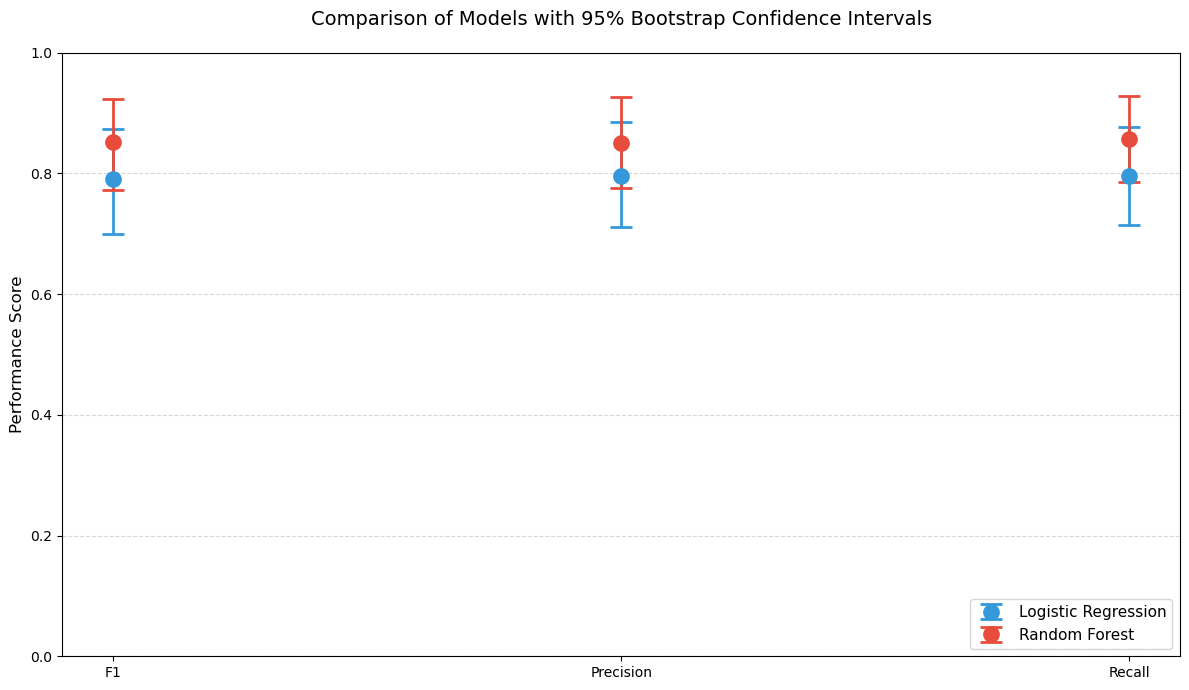

In [118]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 7))
models = results_df['Model'].unique()
colors = ['#3498db', '#e74c3c'] 
for i, model in enumerate(models):
    subset = results_df[results_df['Model'] == model]
    plt.errorbar(x=subset['Metric'], 
                 y=subset['Score'], 
                 yerr=[subset['Score'] - subset['Lower'], subset['Upper'] - subset['Score']],
                 fmt='o',         
                 capsize=8,         
                 label=model, 
                 color=colors[i],
                 markersize=10, 
                 elinewidth=2, 
                 markeredgewidth=2)
plt.title('Comparison of Models with 95% Bootstrap Confidence Intervals', fontsize=14, pad=20)
plt.ylabel('Performance Score', fontsize=12)
plt.ylim(0, 1.0)
plt.legend(loc='lower right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

I recommend the Random Forest model for this classification task. Based on the 95% Bootstrap Confidence Intervals:

Higher Performance: Random Forest consistently achieves higher scores across all three metrics (F1, Precision, and Recall) compared to Logistic Regression.

Reliability: The point estimates (red dots) for Random Forest are visibly higher, and even its lower confidence bounds are comparable to or higher than the average performance of Logistic Regression.

Stability: Although both models show similar interval widths (whiskers), Random Forest's superior accuracy makes it the more robust choice for predicting a car's origin based on its technical specifications.

---
## Task 4 — Summary

Write a short summary (150–250 words) answering:

1. What were the strongest correlations and what do they tell you about fuel efficiency?
2. Do cars from different origins differ significantly? Which groups stand out?
3. Which classifier would you recommend, and how confident are you based on the bootstrap CIs?

Summary of Statistical Analysis and ClassificationThis study investigated the factors influencing vehicle fuel efficiency and evaluated machine learning models for predicting a car's origin based on its technical specifications.The correlation analysis revealed that the strongest relationship exists between weight and MPG (Pearson’s $r = -0.83$). This indicates a powerful inverse relationship, where an increase in vehicle mass significantly compromises fuel efficiency. Additionally, the high positive correlation between cylinders and horsepower ($r = 0.84$) confirms that engine performance remains strictly tied to mechanical configuration.Regarding regional comparisons, One-way ANOVA and Tukey HSD tests confirmed that fuel efficiency differs significantly across all three origins ($p < 0.05$). Japan stands out with the highest fuel efficiency, followed by Europe, while USA models show the lowest performance. The large effect size ($\eta^2 = 0.33$) indicates that the country of origin alone explains approximately 33% of the total variance in MPG, reflecting distinct engineering priorities and regulatory standards across these markets.Finally, I recommend the Random Forest classifier over Logistic Regression. Based on the 95% Bootstrap Confidence Intervals, Random Forest consistently achieved superior results across all metrics, with a stable F1-score of approximately 0.85. Since its confidence intervals are both higher and relatively narrow, I am highly confident that Random Forest is the more robust and reliable model for this dataset.